In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#from scipy.integrate import odeint
from scipy.integrate import solve_ivp  # more modern than odeint
import copy 
import matplotlib.tri as tri
import pprint
import scipy.linalg

notebookroot = 'spin_02_'  


# Hamiltonian model, lets do something quite general with a pile of free parameters 
Classical model
\begin{align}
 H(\phi,p,\tau) &= \frac{a}{2} J_z^2 + \omega_x J_x + \omega_y J_y  + \omega_z J_z \\
 &+ \mu_x J_x  \cos(\tau + \beta_z)  + \mu_y J_y \cos(\tau + \beta_y) 
 + \mu_z J_z\cos(\tau + \beta_z)
 \end{align}
With
\begin{align}
p &= 1- \cos \theta\\
J_x & = \sin \theta \cos \phi  = \sqrt{1 - (p-1)^2} \cos \phi\\
J_y & = \sin \theta \sin \phi  = \sqrt{1 - (p-1)^2} \sin \phi\\
J_z & = \cos \theta = 1 - p
\end{align}
\begin{align}
\frac{\partial J_x}{\partial p} &= \frac{-\cos \phi}{\sqrt{(1 - (p-1)^2)}} (p-1) = \frac{ \cos \theta }{\sin\theta}\cos \phi\\
\frac{\partial J_y}{\partial p} &= \frac{ \cos \theta }{\sin\theta}\sin \phi\\
\frac{\partial J_z}{\partial p} &= -1\\
\frac{\partial J_z^2}{\partial p} &= 2(p-1) = - 2\cos \theta
\end{align}
\begin{align}
\frac{\partial J_x}{\partial \phi} &= - \sqrt{1 - (p-1)^2} \sin \phi \\
\frac{\partial J_y}{\partial \phi} &=  \sqrt{1 - (p-1)^2} \cos \phi \\
\frac{\partial J_z}{\partial \phi} &=  0 
\end{align}

\begin{align}
\frac{\partial H}{\partial p} & = \frac{a}{2} \frac{\partial J_z^2}{\partial p} \\
& + (\omega_x + \mu_x \cos (\tau + \beta_x) ) \frac{\partial J_x}{\partial p} \\
& + (\omega_y + \mu_y \cos (\tau + \beta_y) ) \frac{\partial J_y}{\partial p} \\
& + (\omega_z + \mu_z \cos (\tau + \beta_z) ) \frac{\partial J_z}{\partial p} 
\end{align}

\begin{align}
\frac{\partial H}{\partial \phi} & = \frac{a}{2} \frac{\partial J_z^2}{\partial \phi} \\
& + (\omega_x + \mu_x \cos (\tau + \beta_x) ) \frac{\partial J_x}{\partial \phi} \\
& + (\omega_y + \mu_y \cos (\tau + \beta_y) ) \frac{\partial J_y}{\partial \phi} \\
& + (\omega_z + \mu_z \cos (\tau + \beta_z) ) \frac{\partial J_z}{\partial \phi} 
\end{align}

For $H(\phi,p)$, 
Hamilton's equations 
\begin{align}
\dot \phi &= \frac{\partial H}{\partial p} \\
\dot p &=- \frac{\partial H}{\partial \phi}
\end{align}

In [2]:
# dy/dtau = func(y,tau), needed for integrator! odeint 
# note that y[0] = phi and y[1] = p
# for integrating the classical model, if you use odeint tfirst=True
def cfunc(tau,y,parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    
    phi = y[0]
    p = y[1]  # in [0,2]
    ctheta = 1.0-p   # cosine theta ranges from [1 , -1]
    stheta = np.sqrt(1.0 - ctheta*ctheta)  # if p=0, ctheta =1, theta=0,stheta=0, if p=1 ctheta=0, theta=pi/2, stheta=1
    # sin theta ranges from [0,1] and we don't need to worry about the sign of it
    cphi = np.cos(phi)
    sphi = np.sin(phi)
    
    dJxdp = ctheta/stheta * cphi
    dJydp = ctheta/stheta * sphi
    dJzdp = -1.0
    dJz2dp = 2.0*(p-1.0)
    dJxdphi = -stheta*sphi
    dJydphi =  stheta*cphi
    dJzdphi = 0.0
    dJz2dphi = 0.0
    
    ctx = np.cos(tau + beta_x) 
    cty = np.cos(tau + beta_y) 
    ctz = np.cos(tau + beta_z) 
    
    dHdp = 0.5*a*dJz2dp + (omega_x + mu_x*ctx)*dJxdp + (omega_y + mu_y*cty)*dJydp + (omega_z + mu_z*ctz)*dJzdp
    dHdphi = 0.5*a*dJz2dphi + (omega_x + mu_x*ctx)*dJxdphi + (omega_y + mu_y*cty)*dJydphi + (omega_z + mu_z*ctz)*dJzdphi

    dydt = [dHdp,-dHdphi]  # [dot phi, dot p] 
    return dydt

# the Hamiltonian itself, classical model 
def Have(phi,p,tau,parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    
    #phi = y[0]
    #p = y[1]
    ctheta = 1.0-p
    stheta = np.sqrt(1.0 - ctheta*ctheta)
    cphi = np.cos(phi)
    sphi = np.sin(phi)

    ctx = np.cos(tau + beta_x) 
    cty = np.cos(tau + beta_y) 
    ctz = np.cos(tau + beta_z) 
      
    Jz = ctheta; Jx = cphi*stheta; Jy = sphi*stheta
    Jz2 = ctheta*ctheta 
    H = 0.5*a*Jz2 + (omega_x + mu_x*ctx)*Jx + (omega_y + mu_y*cty)*Jy + (omega_z + mu_z*ctz)*Jz
    return H

# make a string that so we can print parameters
def mk_parmstring(parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    parmstring = r'$a$' + '={:.1f},'.format(a)
    parmstring += r'$\omega$' + '=({:.1f},{:.1f},{:.1f}),'.format(omega_x,omega_y,omega_z)
    parmstring += r'$\mu$' + '=({:.1f},{:.1f},{:.1f}),'.format(mu_x,mu_y,mu_z)
    parmstring += r'$\beta$' + '=({:.1f},{:.1f},{:.1f})'.format(beta_x,beta_y,beta_z)
    return parmstring

-0.19995992706970966 0.5199998708619941


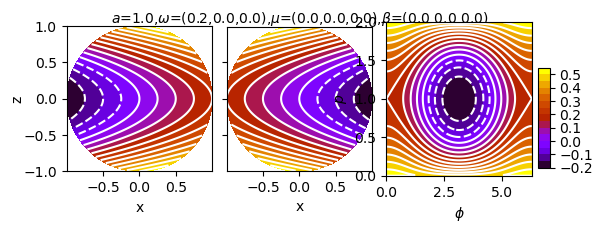

In [3]:
# show level curves of a Hamiltonian model 
def mksfig(phi,p,parms,ofile=''):
    tau = 0.0 
    H = Have(phi,p,tau,parms)  # compute Hamiltonian 
    min_H = np.min(H)
    max_H = np.max(H)
    ctheta = (1.0 - p)
    theta = np.arccos(ctheta)
    stheta = np.sqrt(1-ctheta*ctheta)
    cmap = 'gnuplot'
    
    fig,axarr = plt.subplots(1,3,figsize=(6,2))
    plt.subplots_adjust(wspace=0.1,hspace=0)
    x = np.cos(phi)*stheta
    y = np.sin(phi)*stheta
    z = ctheta 
    ii1 = y>=0; ii2 = y<0
    xshort1 = np.ravel(x[ii1]);  yshort1 = np.ravel(y[ii1]); zshort1 = np.ravel(z[ii1]);
    xshort2 = np.ravel(x[ii2]);  yshort2 = np.ravel(y[ii2]); zshort2 = np.ravel(z[ii2]);
    Hshort1 = np.ravel(H[ii1]);Hshort2 = np.ravel(H[ii2]);
    triang1 = tri.Triangulation(xshort1,zshort1)
    triang2 = tri.Triangulation(-xshort2,zshort2)  # notice flipping x for back side!
    clvs=15; ccolor = 'white'
    im = axarr[0].tricontourf(triang1, Hshort1, cmap =cmap,levels=clvs,vmin=min_H, vmax=max_H)
    im = axarr[1].tricontourf(triang2, Hshort2, cmap =cmap,levels=clvs,vmin=min_H, vmax=max_H)
    cc = axarr[0].tricontour(triang1,Hshort1,levels=clvs,colors=ccolor,vmin=min_H, vmax=max_H)
    axarr[1].tricontour(triang2,Hshort2,levels=clvs,colors=ccolor,vmin=min_H, vmax=max_H)
    axarr[0].set_aspect(1)
    axarr[1].set_aspect(1)
    im = axarr[2].contourf(phi,p,H,origin='lower',cmap = cmap,levels=clvs,vmin=min_H, vmax=max_H)
    im.set_clim(min_H,max_H)
    axarr[2].contour(phi,p,H,origin='lower',levels=clvs,colors=ccolor,vmin=min_H, vmax=max_H)
    axarr[2].set_xlabel(r'$\phi$')
    axarr[2].set_ylabel(r'$p$')
    axarr[0].set_ylabel('z',labelpad=-0.5)
    axarr[0].set_xlabel('x')
    axarr[1].set_xlabel('x')
    axarr[1].set(yticklabels=[])
    parmstring = mk_parmstring(parms) 
    axarr[1].text(0,1.1,parmstring,ha='center',va='center')
    print(np.min(H),np.max(H))
    rect = [0.91,0.15,0.02,0.5] # left, bottom, width, height)
    cax = fig.add_axes(rect)
    plt.colorbar(im,cax=cax,orientation='vertical')  # there is still a problem with not covering whole colormap
    #plt.tight_layout() sucks
    if (len(ofile)>2):
        plt.savefig(ofile)
    
    plt.show()

if (1==1): # test level curve figure
    phi_lin = np.linspace(0,2*np.pi,200)
    p_lin = np.linspace(0,2.0,200)
    phi,p = np.meshgrid(phi_lin,p_lin,indexing='xy') 
    a = 1.0
    omega_x = 0.2; omega_y = 0.0; omega_z = 0.0;
    mu_x = 0.0; mu_y = 0.0; mu_z = 0.0
    beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
    parms = np.zeros(10)
    parms[0] = a
    parms[1] = omega_x
    parms[2] = omega_y
    parms[3] = omega_z 
    parms[4] = mu_x 
    parms[5] = mu_y 
    parms[6] = mu_z 
    parms[7] = beta_x 
    parms[8] = beta_y 
    parms[9] = beta_z 

    ofile = notebookroot+'_H.png'
    mksfig(phi,p,parms,ofile=ofile)


In [16]:
# integrate at a period, the forced top
# arguments:
#   y0: is initial conditions, y=[phi,p]
#   npoints: is number of points we want
#   parms: are parameters of the Hamiltonian model
#
#   integrate every 2 pi period, npoints returned including initial condition 
# returns: 
#     phi_arr,p_arr: arrays of integrated points  
#     status: integration status (0 if good)
# this routine does all times at once by sending a set of times to the integrator
# globals: cfunc(), solve_ivp() is the integrator 
twopi = 2.0*np.pi
def givepoints_arr(y0,npoints,parms):
    # set up time array, every 2pi/nu so for period of perturbation
    step  = twopi
    stop = step*npoints
    t_span = [0,stop]  # range for output times 
    time  = np.arange(0.0,stop,step)  # time array for outputs  goes from 0 to stop-step 
    #                              with increment step, does not reach stop. 
    # do the integration
    #y = odeint(cfunc, y0, time, args=(parms,),rtol=1e-5,tfirst=True)  # notice the comma so it is a tuple
    sol = solve_ivp(cfunc, t_span, y0,t_eval=time,args=(parms,),rtol=1e-6,method='LSODA')  # use more modern caller for integrator
    y = (sol.y).transpose()  # solve_ivp transposes the output
    status = sol.status
    phi_arr = np.squeeze(y[:,0])  # is an array of phi at different times
    p_arr = np.squeeze(y[:,1])    # is an array of momenta at different times
    phi_arr  = phi_arr%twopi  # so that phi remains in [0:2pi]
    return phi_arr,p_arr,status 

colorlist = ['black','blue','green','magenta','red','orange','gold','blueviolet','springgreen','dodgerblue']

# randomly choose an initial condition, integrate and plot in axis ax 
# arguments:
#    npoints: numbers of points to plot 
#    pmin, pmax constrain the vertical width of randomly chosen initial conditions 
#    parms: parameters for the dynamical model 
#    ax  the axis on which to plot points 
def rand_give_points(npoints,parms,pmin,pmax,ax):
    phi = np.random.uniform(low=0,high=2*np.pi)
    p = np.random.uniform(low=pmin,high=pmax)
    y0 = np.array([phi,p])
    phi_arr,p_arr,status =givepoints_arr(y0,npoints,parms)
    if (status ==0):  # only plot if the integration has a good status 
        i = np.random.randint(low=0,high =len(colorlist))
        ax.scatter(phi_arr,p_arr,s=1,edgecolor='none',facecolor=colorlist[i],lw=1)
    return status



In [17]:
# a class to store classical model info
#    norb:  numbers of orbits
#    npoints: numbers of points to plot 
#    a,epsilon,mu,mup,b,taushift: parameters for the dynamical model 
#    froot: a root for labeling files 
class Hcla:
    def __init__(self,norb,npoints,parms,froot):
        self.parms = parms
        self.norb = norb
        self.npoints = npoints
        self.froot = froot       

# make a surface of section figure with orbits 
# inputs: a classical model class and a label
def mkfig_cl(cla,alabel):
    norb = cla.norb
    npoints = cla.npoints
    froot = cla.froot
    parms = cla.parms
    
    # set up display
    fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=200) 
    plt.subplots_adjust(bottom=0.18,top=0.90,left=0.18,right=0.98)
    ax.text(6.2,-0.2,r'$\phi$',fontsize=14)
    ax.set_ylabel('p',labelpad=0,fontsize=14)
    #ax.set_aspect('equal')

    dx = 0.01; dy = 0.01
    ax.set_xlim([-dx,2*np.pi + dx])
    ax.set_ylim([-dy,2+dy])

    #ax.text(0,3.4,parm_label,ha='center',va='center')

    i=0; nerrs=0
    while (i < norb):
        # this many orbits, and plots points
        status = rand_give_points(npoints,parms,0,2,ax)
        if (status ==0):
            i = i+1
        else:
            nerrs += 1
    print('nerrs: ', nerrs);
        
    if (len(alabel)>1):
        plt.text(-0.5,2.2,alabel,fontsize=14)
    if (len(froot)>2):
        ofile = froot + '_class.png'
        print(ofile)
        plt.savefig(ofile,dpi=300)
        
    plt.show()

nerrs:  0


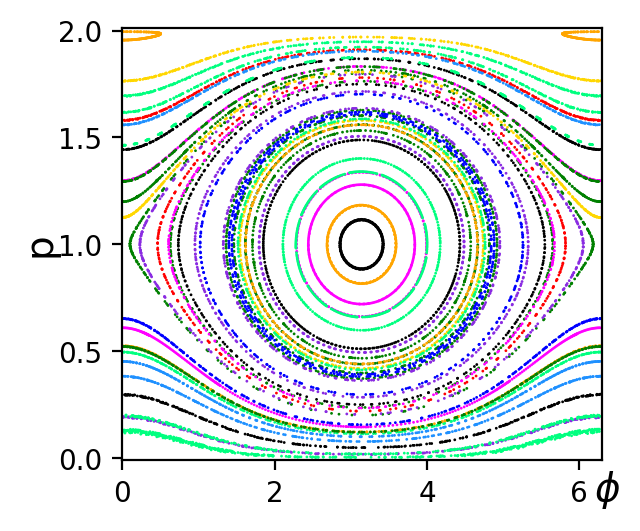

In [18]:
# choose some parameters 
a = 1.0
omega_x = 0.2; omega_y = 0.0; omega_z = 0.0;  # to have a separatrix we need one of these less than parameter a
mu_x = 0.0; mu_y = 0.0; mu_z = 0.0
beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
parms = np.zeros(10)
parms[0] = a
parms[1] = omega_x;  parms[2] = omega_y; parms[3] = omega_z 
parms[4] = mu_x;  parms[5] = mu_y; parms[6] = mu_z 
parms[7] = beta_x; parms[8] = beta_y; parms[9] = beta_z 
norb = 50
npoints = 300
froot = ''
cla_s1 = Hcla(norb,npoints,parms,froot)
alabel = ''
mkfig_cl(cla_s1,alabel)  # non chaotic example 

/var/folders/l_/tk7gphlj0d38754sb6x8p1f00000gn/T/ipykernel_53796/3983218283.py:19: RuntimeWarning: invalid value encountered in sqrt
  stheta = np.sqrt(1.0 - ctheta*ctheta)  # if p=0, ctheta =1, theta=0,stheta=0, if p=1 ctheta=0, theta=pi/2, stheta=1


nerrs:  0


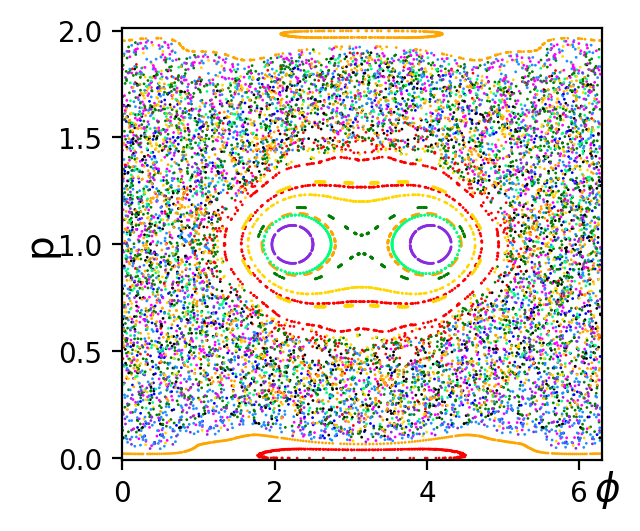

In [7]:
cla_s2 = copy.deepcopy(cla_s1)  #same as s1
mu_x = 0.1
cla_s2.parms[4] = mu_x;
mkfig_cl(cla_s2,alabel)  # 
# I often get a sqrt error but integrator succeeds anyhow?

/var/folders/l_/tk7gphlj0d38754sb6x8p1f00000gn/T/ipykernel_53796/3983218283.py:19: RuntimeWarning: invalid value encountered in sqrt
  stheta = np.sqrt(1.0 - ctheta*ctheta)  # if p=0, ctheta =1, theta=0,stheta=0, if p=1 ctheta=0, theta=pi/2, stheta=1


nerrs:  0


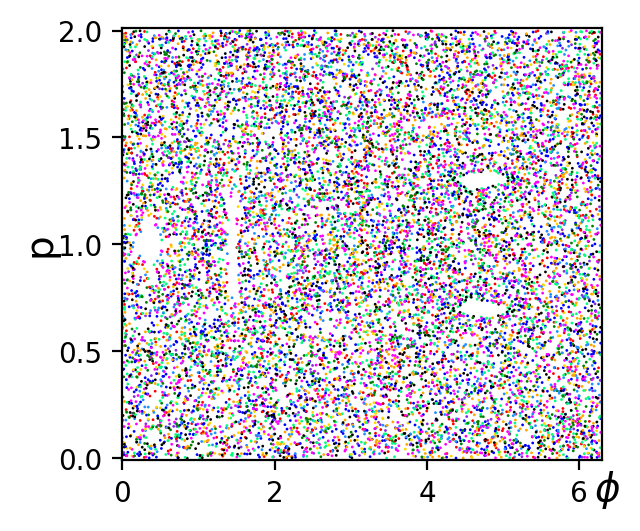

In [8]:
# choose some parameters 
a = 1.5
omega_x = 0.3; omega_y = 0.0; omega_z = 0.0;  # to have a separatrix we need one of these less than a
mu_x = 0.0; mu_y = 3; mu_z = 0.0
beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
parms = np.zeros(10)
parms[0] = a
parms[1] = omega_x;  parms[2] = omega_y; parms[3] = omega_z 
parms[4] = mu_x;  parms[5] = mu_y; parms[6] = mu_z 
parms[7] = beta_x; parms[8] = beta_y; parms[9] = beta_z 
norb = 50
npoints = 300
froot = ''
cla_t1 = Hcla(norb,npoints,parms,froot)
alabel = ''
mkfig_cl(cla_t1,alabel)  # 

For the quantum system we need to create unitary operators 
Jx Jy Jz 


In [9]:
import pprint
# create angular momentum operators  
# basis of Jz |jm> indexed with m, .... -m  corresponding to i=0 to i=2j+1 - 1
def mk_Js(j):
    N = int(2*j+1)
    zdiag = np.arange(-j,j+1,1,dtype=complex) # order m = -j to +j
    zdiag_flip = np.flip(zdiag)  # order j to -j
    #pprint.pprint(zdiag_flip)
    Jz = np.diag(zdiag_flip)
    Jplus  = np.zeros((N,N),dtype=complex)
    Jminus = np.zeros((N,N),dtype=complex)
    for k in range(0,N-1):
        m = Jz[k,k]
        #print(m)
        #c_jm_plus  = (j - m)*(j + m + 1) # for raising jm
        #cp = j*(j + 1) - m*(m + 1)  # 
        #Jplus[k+1,k] = np.sqrt(cp)
        cm  = j*(j + 1) - m*(m - 1) 
        #print(cm)
        Jminus[k+1,k] = np.sqrt(cm)
    #Jminus = np.transpose(Jplus) # is real so we don't need to conjugate
    Jplus = np.transpose(Jminus) # is real so we don't need to conjugate
    Jx =  0.5 *(Jplus + Jminus)
    Jy = -0.5j*(Jplus - Jminus)
    return Jminus,Jplus,Jx,Jy,Jz



Associated Quantum model 
\begin{align}
 \hat H(\tau) &= \frac{a}{2j} J_z^2 + \omega_x J_x + \omega_y J_y  + \omega_z J_z \\
 &+ \mu_x J_x  \cos(\tau + \beta_z)  + \mu_y J_y \cos(\tau + \beta_y) 
 + \mu_z J_z\cos(\tau + \beta_z)
 \end{align}

## we can use a second order Trotterization formula
With $H = A + B + C$

$$e^{iH\tau } \approx e^{iA\tau/2} e^{iB\tau/2} e^{iC\tau} e^{iB\tau/2} e^{iA\tau/2} + {\cal O}(\tau^3)$$
We split the Hamiltonian into terms that depend on $J_x$, those that depend on $J_y$ and those 
that depend on $J_z$.  Look up Suzuki 92 to make sure this is correct. 
There is a paper on Trotterization (product formula) by Childs and collaborators. 

I checked this formula via expansion and it is okay to second order. 

In [10]:
# construct the unperturbed quantum Hamiltonian
# we don't use the mu's
# we will need this routine to sort the eigenvectors 
def mkH0(j,parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    #mu_x = parms[4]; mu_y = parms[5]; mu_z = parms[6]
    #beta_x = parms[7];  beta_y = parms[8]; beta_z = parms[9]
    ctx = 0.0; cty = 0.0; ctz = 0.0
    mu_x = 0.0; mu_y = 0.0; mu_z = 0.0; 
    Jminus,Jplus,Jx,Jy,Jz = mk_Js(j)
    Jz2 = np.matmul(Jz,Jz)
    H_x = (omega_x  + mu_x*ctx)*Jx
    H_y = (omega_y  + mu_y*cty)*Jy
    H_z = (omega_z  + mu_z*ctz)*Jz + a*Jz2/(2*j) 
    H0_total = H_x + H_y + H_z
    return H0_total 

# compute the expectation value of operator, using a state vector evec
def exp_val(evec,op):
    zvec = np.matmul(op,evec)   # compute op|evec>
    w = np.vdot(evec,zvec)   # complex dot product, evec is conjugated prior to doing the dot product
    return w

# sort a set of eigenvalues and eigenfunctions according to the expectation value of an operator
# returns expectation values and dispersions
# arguments:
#  w is list of eigenvals
#  vr is list of eigenvectors
#  op is operator that you want to use to sort
# returns:
#   wsort: list of eigenvalues but these are in order of exp of op
#     computed with the eigenvecs
#   vrsort: list of eigenvecs but in order of <op>
#   expsort:  the expectation values <op>
#   sigsort:  the dispersion values (not standard deviations)
# calls exp_val()
def esort_op(w,vr,op):
    n = len(w)
    exp_arr = np.zeros(n,dtype=complex) # to store the expectation values  <op>
    sig_arr = np.zeros(n,dtype=complex) # to store <op^2> - <op>^2
    for i in range(n):
        mu =  exp_val(np.squeeze(vr[:,i]), op)  #h
        mu2 = exp_val(np.squeeze(vr[:,i]), np.matmul(op,op)) #h^2
        sig2 = mu2-mu*mu # compute dispersion too
        exp_arr[i] = mu
        sig_arr[i] = sig2  # notice is dispersion not std
        # compute the expectation values of the operator for every eigenfunction
    iphi = np.argsort(np.real(exp_arr)) # sort in order of increasing expectation value
    wsort = w[iphi]  # sort the eigenvalues
    expsort = exp_arr[iphi] # sort the expectation values
    sigsort = sig_arr[iphi] # sort the dispersions
    vrsort = np.copy(vr)*0.0 # to store the eigenfunctions in order of expectation vals
    for i in range(len(w)):
        vrsort[:,i] = vr[:,iphi[i]]  # sort the eigenfunctions which are vr[:,j]

    return wsort,vrsort,expsort,sigsort

# contruct the Floquet propagator 
# ntau is the number of steps to divide the 2 pi time interval into 
# calls mk_Js()
# doing a second order Suzuki-Trotterization  by dividing the Hamiltonian in 3 pieces 
def Uprop(j,ntau,parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    Jminus,Jplus,Jx,Jy,Jz = mk_Js(j)
    Jz2 = np.matmul(Jz,Jz)
    dtau = 2*np.pi/int(ntau)
    N = int(2*j+1)
    U = np.identity(N,dtype=complex)
    for i in range(ntau): # each dtau
        tau = i*dtau 
        ctx = np.cos(tau + beta_x) 
        cty = np.cos(tau + beta_y) 
        ctz = np.cos(tau + beta_z)  
        H_x = (omega_x  + mu_x*ctx)*Jx
        H_y = (omega_y  + mu_y*cty)*Jy
        H_z = (omega_z  + mu_z*ctz)*Jz + a*Jz2/(2*j)  # notice the 2j here!!!!!
        A1 = scipy.linalg.expm(-0.5j*dtau*H_x)  # half steps
        B1 = scipy.linalg.expm(-0.5j*dtau*H_y)
        C1 = scipy.linalg.expm(-1.0j*dtau*H_z)   # full step 
        #pprint.pprint(C1) 
        Ustep = np.matmul(A1,np.matmul(B1,np.matmul(C1,np.matmul(B1,A1))))
        U = np.matmul(Ustep,np.copy(U))
    (w,vr)=np.linalg.eig(U)  # compute eigenvalues 
    return w,vr,U # is this ok? yes  

# check to see if an np.array square matrix m is unitary 
def is_unitary(m):
    bb = np.allclose(np.eye(len(m)), m.dot(m.T.conj()), rtol=1e-05, atol=1e-08) # for square numpy array m
    return bb  # returns boolean



### Phase space
This is a spin coherent state according to Liz' paper Champion+26
$$|\theta, \phi \rangle = e^{−i\phi J_z} e^{−i\theta J_y} |j, j\rangle$$
and can be computed for any $\theta, \phi$ on the sphere.
This one makes sense to me as it is consistent with the Euler angle rotations. 

In the Haake_87 paper equation 2.6
$$|\theta, \phi \rangle = (1 + \gamma \gamma*)^{-j}e^{\gamma J_-} | j,j \rangle$$
with $\gamma = e^{i\phi} \tan \frac{\theta}{2}$
This is consistent with the Arecchi+72 paper and it is also used but starting from -m 
in the paper by Castanos+06.  Seems like this is more common that the spin coherent state version used by Liz. 
I checked and both are normalized and their dot product is 1 so they only differ in phase!
 

In [11]:
# create the spin coherent state |theta,phi> = e^{-i phi Jz} e^{-i theta Jy) |j,j>
# this is the recipe from Liz's paper which is not exactly the same as in Haake+87's paper
# or in Arecchi+72 - they seem to only differ by a phase! 
# calls mk_Js()
# note that theta is passed here 
# this routine is more robust than the Haa one because it does not overflow 
def spin_coherent_Liz(j,theta,phi):
    Jminus,Jplus,Jx,Jy,Jz = mk_Js(j)
    N = int(2*j+1)
    jjvec = np.zeros(N,dtype = complex)
    jjvec[0] = 1.0 # this should be the jj state as we are ordering it first
    ephi = scipy.linalg.expm(-1j*phi*Jz)
    etheta = scipy.linalg.expm(-1j*theta*Jy)
    ephitheta = np.matmul(ephi,etheta)
    coherent_state = np.matmul(ephitheta,jjvec)
    return coherent_state



In [13]:
# fill a matrix with spin coherent states 
# put them in a matrix [nn,nn,N=2j+1]  where nn = N unless N<25 in which case it is 25
# the sampling is with respect to p, phi 
# returns 
#   coh_matrix [nn,nn,2j+1] 
#   phi,p,theta grids 
#   ctype:  Choose Liz or Haa to determine which function is used to make coherent states 
# calls: spin_coherent_Liz(), mk_Js()  
def mk_spin_coh(j):
    N = int(2*j+1)
    nn = N
    if (N < 25):
        nn = 25
    phi_lin = np.linspace(0,2*np.pi,nn)
    p_lin = np.linspace(0,2.0,nn)
    phi,p = np.meshgrid(phi_lin,p_lin,indexing='xy') # grid of phi,p
    ctheta = 1 - p # grid of cosine theta
    theta = np.arccos(ctheta)  # grid of thetas 
    coh_matrix = np.zeros((nn,nn,N),dtype=complex)
    for a in range(nn):
        for b in range(nn):
            phi_ab = phi[a,b]
            theta_ab = theta[a,b]
            #if (ctype=='Liz'):  # use this one!
            coh_matrix[a,b,:] = spin_coherent_Liz(j,theta_ab,phi_ab)  ### if you want the other coherent state routine replace here!
            #else: 
            #    coh_matrix[a,b,:] = spin_coherent_Haa(j,theta_ab,phi_ab)   # can overflow if j is an integer 
    return coh_matrix,phi,p,theta

# compute Husimi distribution using all spin coherent states in the matrix coh_matrix 
# which is computed using mk_spin_coh() for the quantum state psi
# and contains an array of spin coherent states 
def Husimi(psi,coh_matrix):
    nx = coh_matrix.shape[0]
    ny = coh_matrix.shape[1]
    Hmatrix = np.zeros((nx,ny),dtype =float)
    for a in range(nx):
        for b in range(ny):
            coh = np.squeeze(coh_matrix[a,b,:]) # is a coherent state 
            hh = np.vdot(psi,coh)
            mag = np.abs(hh)
            Hmatrix[a,b] = mag*mag # should be real 
    return Hmatrix   # result is nx x ny

# compute and store Husimi distributions for all eigenfunctions in an nx times ny time N array
# arguments:
#    vr eigenvectors  (NxN) matrix but eigenvectors are [:,j]
#    coh_matrix nx x ny x N matrix of coherent states, precomputed with mk_spin_coh(j)
# returns matrix of Husimi distributions
def stor_Hus(vr,coh_matrix):
    vshape = vr.shape; 
    cshape = coh_matrix.shape
    N =vshape[0]
    nx = cshape[0]
    ny = cshape[1]

    Hmatrix_big = np.zeros((nx,ny,N))  # allocate memory
    # one husimi distribution per eigenstate 
    for k in range(N):   # loop over eigenstates
        Hmatrix_big[:,:,k]= Husimi(np.squeeze(vr[:,k]),coh_matrix) # last index is for eigenstate 
    return Hmatrix_big



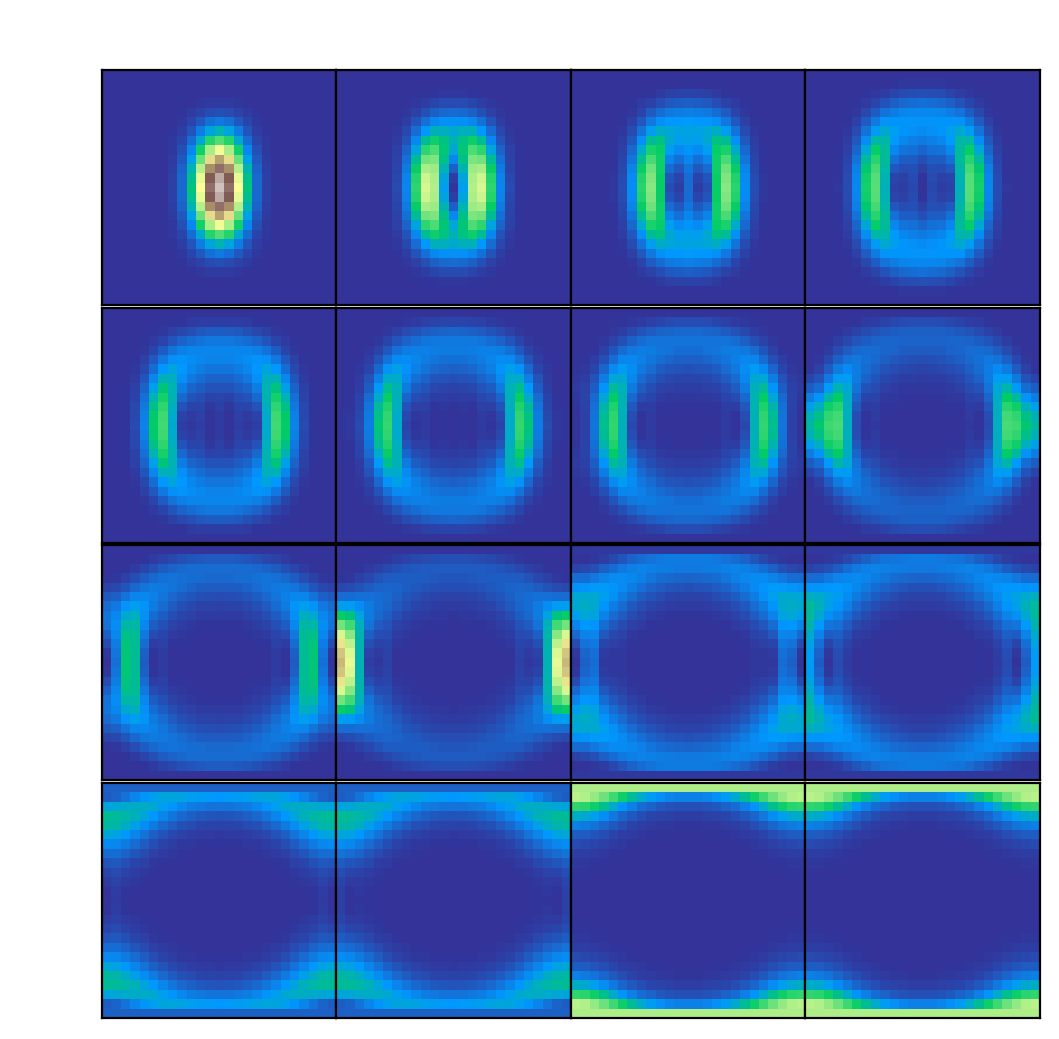

-0.2 0.5000694142774342


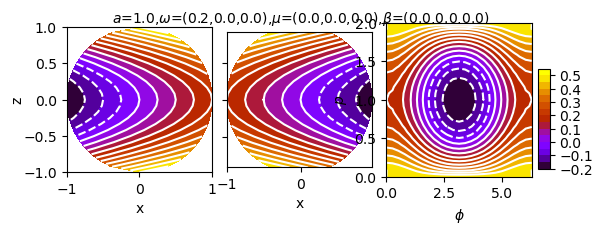

In [15]:
# show Husimi functions for all eigenfunctions
# arguments:
#  Hmatrix_big: matrix of Husimi functions, precomputed
#  pcolorbar = True/False, whether or not you want to show the colorbar
import matplotlib.ticker as mticker
def show_Hus(Hmatrix_big,zmax=0.1,froot='',pcolorbar=False,ablabel=None,toplabel=None):
    if (hasattr(Hmatrix_big, "__len__") == False):
        exit
    hshape = Hmatrix_big.shape;
    nx =hshape[0] # these are the dimensions of the husimi distributions 
    ny =hshape[1]
    N = hshape[2] # this is the number of Hussimi distributions  
    sn = int(np.sqrt(N))
    if (N - sn*sn>0):
        sn+=1;   #increase number of square so that all states are displayed

    fig,axarr = plt.subplots(sn,sn,figsize=(5.1,5.0),sharex=True,sharey=True,dpi=200)
    plt.subplots_adjust(hspace=0,wspace=0,left=0.08,right=1.0,top=0.95,bottom=0.0);
    axarr[0,0].set_xticks([])
    axarr[0,0].set_yticks([])
    #zmax = 1/sn  # could be adjusted!!!! or it could become an argument
    
    ax=fig.add_axes([0,0,1,1],frame_on = False)
    ax.set_xticks([])
    ax.set_yticks([])
    if (N < 200):
        if (ablabel!=None):
            ax.text(0.00,0.94,ablabel,transform=ax.transAxes,fontsize=26)
            
    if (toplabel!=None):
        ax.text(0.077,0.88,toplabel,transform=ax.transAxes,fontsize=20,ha='right',\
            va='top')
    
    #for i in range(sn):
    #    for jj in range(sn):
    #        axarr[i,jj].set_aspect('equal')
    nhalf = (int)(N/2)
    
    for i in range(sn):   # plots are in y direction from top to down
        for jj in range(sn):  # plots in x direction from left to right
            k = i*sn + jj  # incrementing horizontally first
            if (k < N):
                Hmatrix_k = np.squeeze(Hmatrix_big[:,:,k])
                #Hmatrix_b = np.roll(Hmatrix_k, nhalf, axis=0) # shift 0,0 to center of image
                #Hmatrix = np.roll(Hmatrix_b, nhalf, axis=1)
                im=axarr[i,jj].imshow(Hmatrix_k,origin='lower',vmin=0,\
                                     vmax=zmax,cmap='terrain') # flips y direction of display
                if (k==0):
                    im0 = im
    
    if (pcolorbar==True):
        cax=fig.add_axes([0.055,0.03,0.02,0.5])
        cbar = plt.colorbar(im0,cax=cax,ticks = [0,zmax],location='left',format=mticker.FixedFormatter(['0', '']))
        ccc = '{:.3e}'.format(zmax)
        cax.text(0.5,zmax*1.02,ccc,fontsize=8,rotation='vertical',va='bottom',ha='center')

    #axarr[0,0].plot([0],[0],'ro')
    
    if (len(froot)>2):
        ofile = froot + '_Hus.png'
        plt.savefig(ofile,dpi=200)
    plt.show()


if (1==1):   # tests! non chaotic one
    j =7.5
    
    a = 1.0
    omega_x = 0.2; omega_y = 0.0; omega_z = 0.0;  # to have a separatrix we need one of these less than a
    mu_x = 0.0; mu_y = 0.0; mu_z = 0.0
    beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
    parms = np.zeros(10)
    parms[0] = a
    parms[1] = omega_x;  parms[2] = omega_y; parms[3] = omega_z 
    #parms[4] = mu_x;  parms[5] = mu_y; parms[6] = mu_z 
    #parms[7] = beta_x; parms[8] = beta_y; parms[9] = beta_z 

    ntau = 20
    w,vr,U = Uprop(j,ntau,parms)
    h0_op = mkH0(j,parms)
    wsort,vrsort,expsort,sigsort = esort_op(w,vr,h0_op)

    coh_matrix,phi,p,theta = mk_spin_coh(j)  # make the spin coherent states!
    Hmatrix_big = stor_Hus(vrsort,coh_matrix)
    show_Hus(Hmatrix_big,zmax=1)
    
    mksfig(phi,p,parms)

    # the result is that it does not matter which type of coherent state we use, they both are  the same!
    # this I think resembles the classical model 